In [1]:
#sys setup
import sys
print(sys.executable)


/home/rohith/Documents/UH_DataScience/ds-chatbot/.venv/bin/python


In [2]:
#loading datasets
import pandas as pd
train = pd.read_csv("../data/raw/train.csv")
test  = pd.read_csv("../data/raw/test.csv")
print("Train shape:", train.shape)
print("Test shape :", test.shape)
print("Columns:", train.columns.tolist())
train.head()


Train shape: (10003, 2)
Test shape : (3080, 2)
Columns: ['text', 'category']


,text,category
0,I am still waiting on my card?,card_arrival
1,What can I do if my card still hasn't arrived ...,card_arrival
2,I have been waiting over a week. Is the card s...,card_arrival
3,Can I track my card while it is in the process...,card_arrival
4,"How do I know if I will get my card, or if it ...",card_arrival


In [3]:
test.head()

,text,category
0,How do I locate my card?,card_arrival
1,"I still have not received my new card, I order...",card_arrival
2,I ordered a card but it has not arrived. Help ...,card_arrival
3,Is there a way to know when my card will arrive?,card_arrival
4,My card has not arrived yet.,card_arrival


In [4]:
train.isna().sum()#missing values


text        0
category    0
dtype: int64

/tmp/ipykernel_5984/1234926402.py:10: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


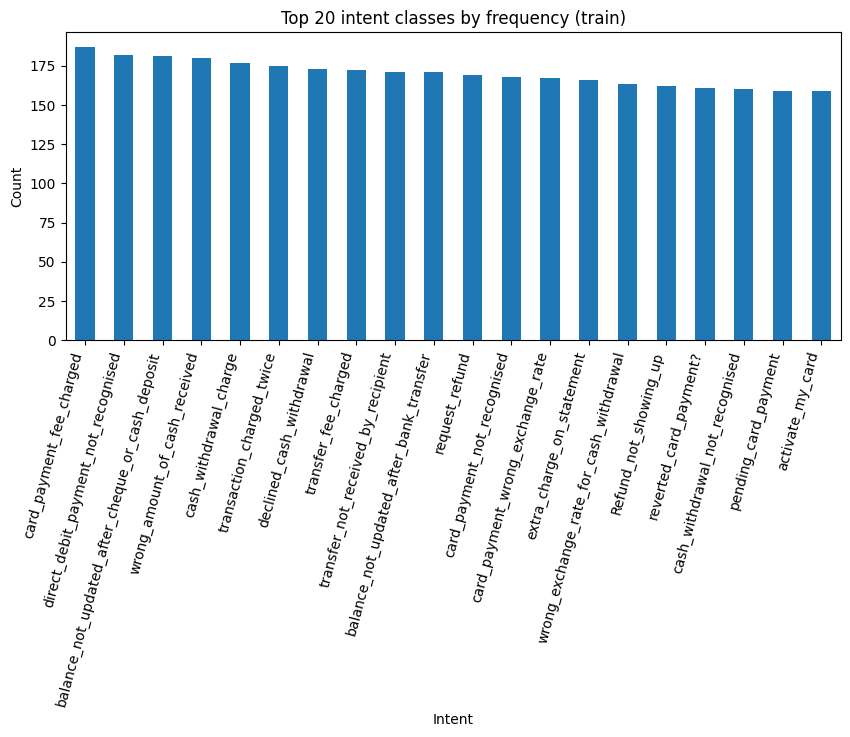

In [5]:
#eda
import matplotlib.pyplot as plt #top 20 classes
intent_counts = train["category"].value_counts()
plt.figure(figsize=(10,4))
intent_counts.head(20).plot(kind="bar")
plt.title("Top 20 intent classes by frequency (train)")
plt.xlabel("Intent")
plt.ylabel("Count")
plt.xticks(rotation=75, ha="right")
plt.tight_layout()
plt.show()



In [6]:
print("Min samples per intent:", intent_counts.min())#summary of class distribution
print("Max samples per intent:", intent_counts.max())
print("Mean samples per intent:", round(intent_counts.mean(), 2))

Min samples per intent: 35
Max samples per intent: 187
Mean samples per intent: 129.91


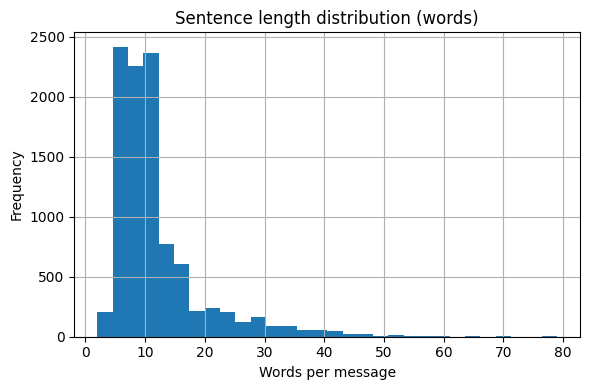

count    10003.000000
mean        11.949415
std          7.891577
min          2.000000
25%          7.000000
50%         10.000000
75%         13.000000
max         79.000000
Name: text_len, dtype: float64

In [7]:
train["text_len"] = train["text"].astype(str).str.split().str.len()
plt.figure(figsize=(6,4))
train["text_len"].hist(bins=30)
plt.title("Sentence length distribution (words)")
plt.xlabel("Words per message")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

train["text_len"].describe()


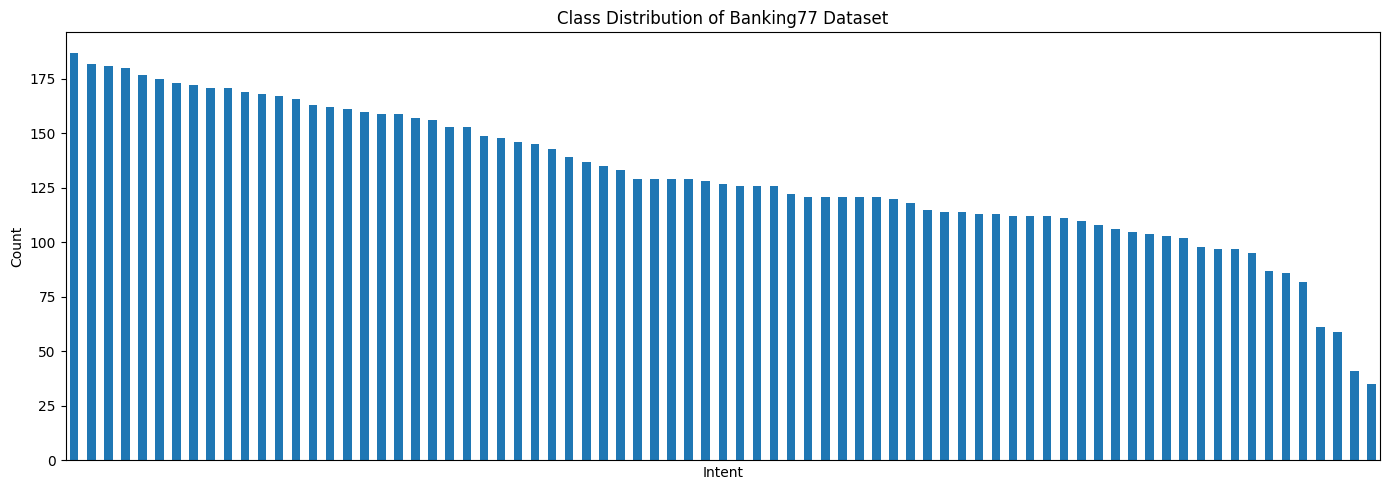

In [8]:
plt.figure(figsize=(14,5))
intent_counts.plot(kind="bar")
plt.title("Class Distribution of Banking77 Dataset")
plt.xlabel("Intent")
plt.ylabel("Count")
plt.xticks([], [])  # hide labels because there are too many classes
plt.tight_layout()
plt.show()

In [9]:
print("Number of intent classes:", train["category"].nunique())
print("Average text length:", round(train["text_len"].mean(), 2))
print("Median text length:", train["text_len"].median())

Number of intent classes: 77
Average text length: 11.95
Median text length: 10.0


In [10]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split

In [11]:
X = train["text"]
y = train["category"]
X_train, X_val, y_train, y_val = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)
tfidf = TfidfVectorizer(
    ngram_range=(1,2),
    min_df=2,
    max_df=0.9
)

In [12]:
X_train_tfidf = tfidf.fit_transform(X_train)
X_val_tfidf = tfidf.transform(X_val)

X_train_tfidf.shape

(8002, 8903)

In [13]:
print("Vocabulary size:", len(tfidf.vocabulary_))

Vocabulary size: 8903


In [14]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(
    max_iter=3000,
    n_jobs=-1
)

model.fit(X_train_tfidf, y_train)

/home/rohith/Documents/UH_DataScience/ds-chatbot/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [15]:
from sklearn.metrics import accuracy_score, classification_report

y_pred = model.predict(X_val_tfidf)

print("Validation Accuracy:", accuracy_score(y_val, y_pred))
print(classification_report(y_val, y_pred))

Validation Accuracy: 0.8440779610194903
                                                  precision    recall  f1-score   support

                           Refund_not_showing_up       0.97      0.91      0.94        32
                                activate_my_card       0.97      0.94      0.95        32
                                       age_limit       1.00      0.91      0.95        22
                         apple_pay_or_google_pay       0.96      0.96      0.96        25
                                     atm_support       0.74      0.82      0.78        17
                                automatic_top_up       1.00      0.84      0.91        25
         balance_not_updated_after_bank_transfer       0.76      0.76      0.76        34
balance_not_updated_after_cheque_or_cash_deposit       0.84      0.86      0.85        36
                         beneficiary_not_allowed       0.81      0.81      0.81        31
                                 cancel_transfer       0.85

In [16]:
from sklearn.metrics import ConfusionMatrixDisplay


<Figure size 1000x1000 with 0 Axes>

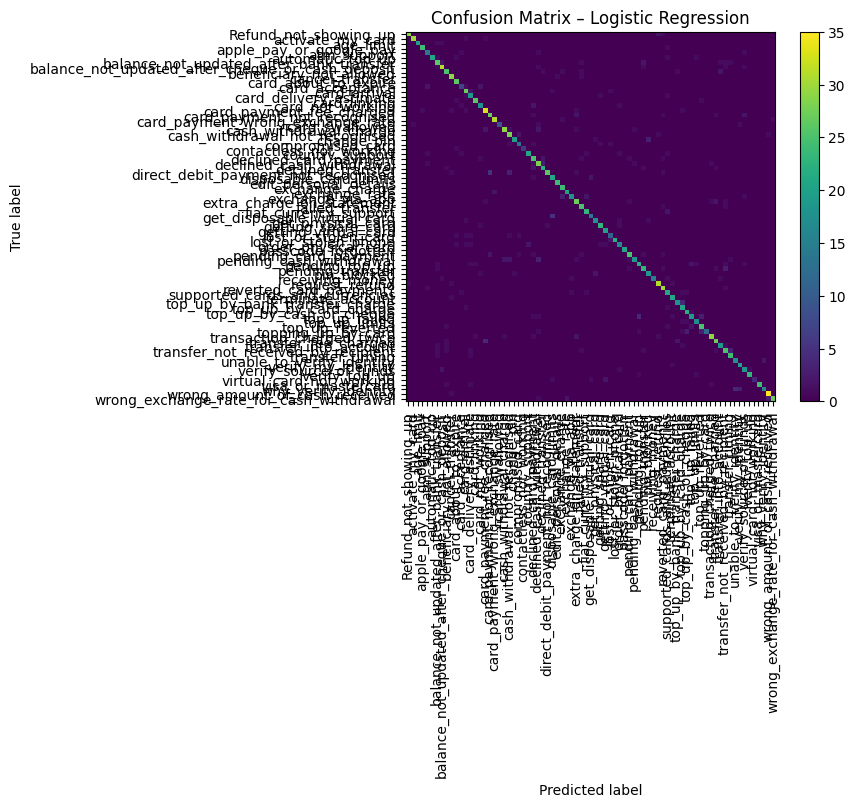

In [17]:
plt.figure(figsize=(10,10))
ConfusionMatrixDisplay.from_predictions(
    y_val,
    y_pred,
    xticks_rotation=90,
    include_values=False
)
plt.title("Confusion Matrix – Logistic Regression")
plt.show()

svm model


In [18]:
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score, classification_report

svm_model = LinearSVC()
svm_model.fit(X_train_tfidf, y_train)

svm_pred = svm_model.predict(X_val_tfidf)

print("SVM Validation Accuracy:", accuracy_score(y_val, svm_pred))
print(classification_report(y_val, svm_pred))

SVM Validation Accuracy: 0.88055972013993
                                                  precision    recall  f1-score   support

                           Refund_not_showing_up       0.91      0.94      0.92        32
                                activate_my_card       0.97      0.94      0.95        32
                                       age_limit       0.95      0.95      0.95        22
                         apple_pay_or_google_pay       1.00      0.96      0.98        25
                                     atm_support       0.88      0.88      0.88        17
                                automatic_top_up       1.00      0.92      0.96        25
         balance_not_updated_after_bank_transfer       0.81      0.76      0.79        34
balance_not_updated_after_cheque_or_cash_deposit       0.89      0.92      0.90        36
                         beneficiary_not_allowed       0.84      0.87      0.86        31
                                 cancel_transfer       1.

<Figure size 1200x1200 with 0 Axes>

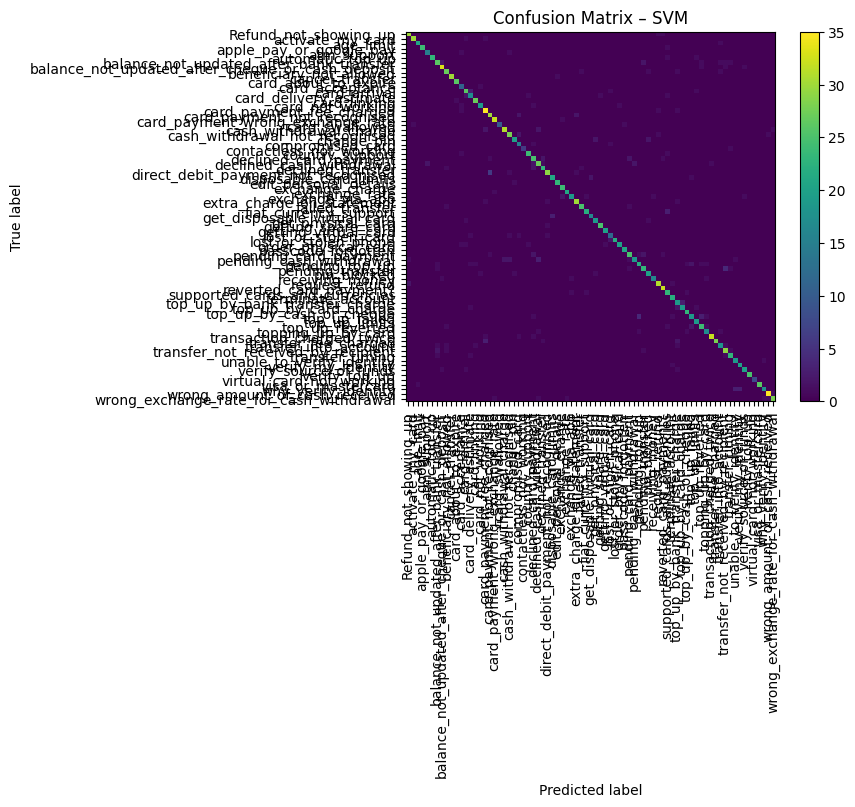

In [19]:
plt.figure(figsize=(12,12))
ConfusionMatrixDisplay.from_predictions(
    y_val,
    svm_pred,
    xticks_rotation=90,
    include_values=False
)
plt.title("Confusion Matrix – SVM")
plt.show()

## SVM Hyperparameter Tuning

In [20]:
from sklearn.svm import LinearSVC
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, classification_report
import pandas as pd

param_grid = {
    "C": [0.01, 0.1, 1, 10]
}

grid_svm = GridSearchCV(
    LinearSVC(),
    param_grid,
    cv=3,
    scoring="f1_macro",
    n_jobs=-1,
    return_train_score=True
)

grid_svm.fit(X_train_tfidf, y_train)

print("Best Parameters:", grid_svm.best_params_)
print("Best CV Score:", grid_svm.best_score_)

# show all tested C values and their CV scores
cv_results_df = pd.DataFrame(grid_svm.cv_results_)

print(
    cv_results_df[
        [
            "param_C",
            "mean_test_score",
            "std_test_score",
            "rank_test_score",
            "mean_train_score"
        ]
    ].sort_values("param_C")
)


Best Parameters: {'C': 1}
Best CV Score: 0.8550266157463677
   param_C  mean_test_score  std_test_score  rank_test_score  mean_train_score
0     0.01         0.750280        0.005132                4          0.870737
1     0.10         0.819898        0.003880                3          0.958442
2     1.00         0.855027        0.008873                1          0.998557
3    10.00         0.852709        0.006346                2          0.999822


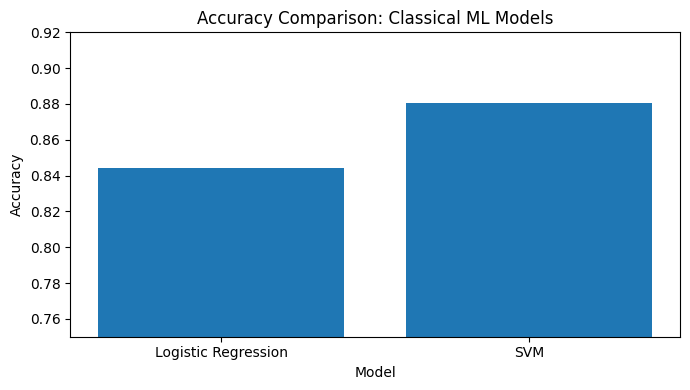

In [21]:

models = ["Logistic Regression", "SVM"]
accuracies = [
    accuracy_score(y_val, y_pred),
    accuracy_score(y_val, svm_pred)
]

plt.figure(figsize=(7,4))
plt.bar(models, accuracies)
plt.title("Accuracy Comparison: Classical ML Models")
plt.xlabel("Model")
plt.ylabel("Accuracy")
plt.ylim(0.75, 0.92)
plt.tight_layout()
plt.show()

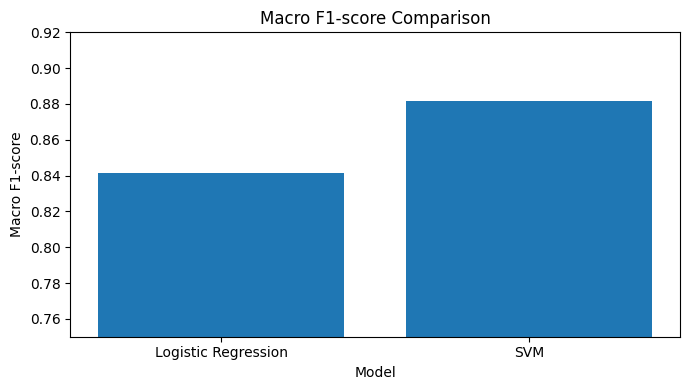

In [22]:
from sklearn.metrics import classification_report
import pandas as pd

lr_report_dict = classification_report(y_val, y_pred, output_dict=True)
svm_report_dict = classification_report(y_val, svm_pred, output_dict=True)

macro_f1_scores = [
    lr_report_dict["macro avg"]["f1-score"],
    svm_report_dict["macro avg"]["f1-score"]
]

plt.figure(figsize=(7,4))
plt.bar(["Logistic Regression", "SVM"], macro_f1_scores)
plt.title("Macro F1-score Comparison")
plt.xlabel("Model")
plt.ylabel("Macro F1-score")
plt.ylim(0.75, 0.92)
plt.tight_layout()
plt.show()

In [23]:
# SVM classification report 
svm_report_df = pd.DataFrame(classification_report(y_val, svm_pred, output_dict=True)).transpose()
svm_report_df.head()


,precision,recall,f1-score,support
Refund_not_showing_up,0.909091,0.937500,0.923077,32.0
activate_my_card,0.967742,0.937500,0.952381,32.0
age_limit,0.954545,0.954545,0.954545,22.0
apple_pay_or_google_pay,1.000000,0.960000,0.979592,25.0
atm_support,0.882353,0.882353,0.882353,17.0


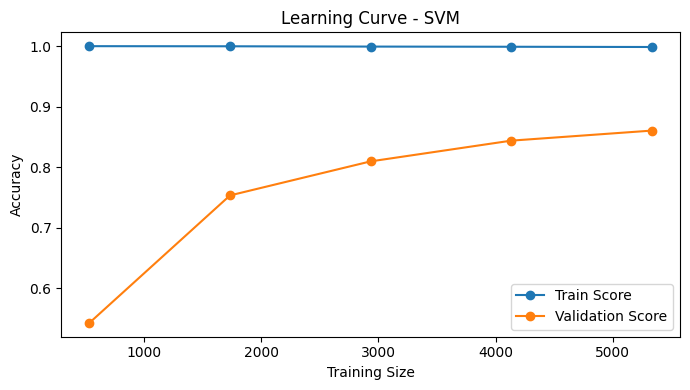

In [24]:
#learning curve for SVM
from sklearn.model_selection import learning_curve
import numpy as np

train_sizes, train_scores, val_scores = learning_curve(
    svm_model,
    X_train_tfidf,
    y_train,
    cv=3,
    scoring='accuracy',
    n_jobs=-1,
    train_sizes=np.linspace(0.1, 1.0, 5)
)

train_mean = train_scores.mean(axis=1)
val_mean = val_scores.mean(axis=1)

plt.figure(figsize=(7,4))
plt.plot(train_sizes, train_mean, marker='o', label="Train Score")
plt.plot(train_sizes, val_mean, marker='o', label="Validation Score")
plt.xlabel("Training Size")
plt.ylabel("Accuracy")
plt.title("Learning Curve - SVM")
plt.legend()
plt.tight_layout()
plt.show()

## Neural Network Model

In [25]:
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from sklearn.model_selection import train_test_split


I0000 00:00:1776826984.101609    5984 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1776826984.108181    5984 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1776826984.814480    5984 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1776826986.363117    5984 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.

In [26]:
# Encode labels
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(train["category"])

In [27]:
# Tokenize text
tokenizer = Tokenizer(num_words=5000)
tokenizer.fit_on_texts(train["text"])


In [28]:
X_seq = tokenizer.texts_to_sequences(train["text"])


In [29]:
# Pad sequences to same length
X_pad = pad_sequences(X_seq, maxlen=20)

print("Input shape:", X_pad.shape)
print("Number of classes:", len(label_encoder.classes_))

Input shape: (10003, 20)
Number of classes: 77


In [30]:
X_train_nn, X_val_nn, y_train_nn, y_val_nn = train_test_split(
    X_pad,
    y_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded
)

print("Train shape:", X_train_nn.shape)
print("Validation shape:", X_val_nn.shape)

Train shape: (8002, 20)
Validation shape: (2001, 20)


In [31]:
#SIMPLE NEURAL NETWORK
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, Flatten, Dense

In [32]:
nn_model = Sequential([
    Embedding(input_dim=5000, output_dim=64, input_length=20),
    Flatten(),
    Dense(128, activation='relu'),
    Dense(77, activation='softmax')
])

nn_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

nn_model.summary()

/home/rohith/Documents/UH_DataScience/ds-chatbot/.venv/lib/python3.12/site-packages/keras/src/layers/core/embedding.py:103: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(
E0000 00:00:1776826987.219017    5984 cuda_executor.cc:1737] INTERNAL: CUDA Runtime error: Failed call to cudaGetRuntimeVersion: Error loading CUDA libraries. GPU will not be used.: Error loading CUDA libraries. GPU will not be used.
W0000 00:00:1776826987.219347   15829 cuda_executor.cc:1755] Failed to determine cuDNN version (Note that this is expected if the application doesn't link the cuDNN plugin): INTERNAL: cuDNN error: CUDNN_STATUS_INTERNAL_ERROR
W0000 00:00:1776826987.244918    5984 gpu_device.cc:2365] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
S

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [33]:
# Train neural network
history = nn_model.fit(
    X_train_nn,
    y_train_nn,
    validation_data=(X_val_nn, y_val_nn),
    epochs=5,
    batch_size=32
)

Epoch 1/5
251/251 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.1228 - loss: 3.9157 - val_accuracy: 0.3428 - val_loss: 2.7113
Epoch 2/5
251/251 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.5761 - loss: 1.7539 - val_accuracy: 0.6487 - val_loss: 1.3550
Epoch 3/5
251/251 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8018 - loss: 0.8229 - val_accuracy: 0.7061 - val_loss: 1.0343
Epoch 4/5
251/251 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8952 - loss: 0.4649 - val_accuracy: 0.7511 - val_loss: 0.8613
Epoch 5/5
251/251 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9409 - loss: 0.2828 - val_accuracy: 0.7731 - val_loss: 0.8071


In [34]:
loss, acc = nn_model.evaluate(X_val_nn, y_val_nn)
print("Neural Network Validation Accuracy:", acc)

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7731 - loss: 0.8071  
Neural Network Validation Accuracy: 0.7731134295463562


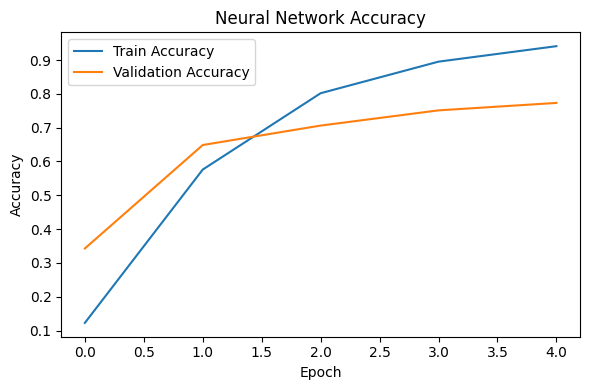

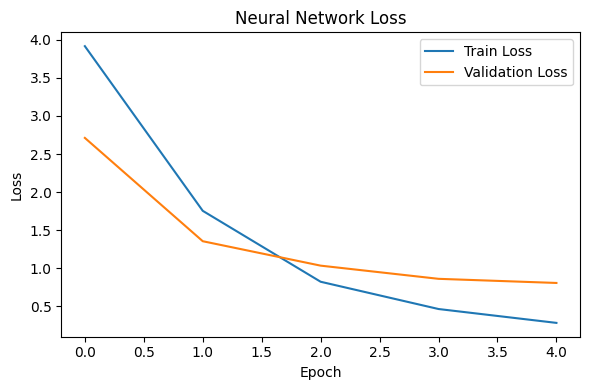

In [35]:
import matplotlib.pyplot as plt

# Accuracy plot
plt.figure(figsize=(6,4))
plt.plot(history.history["accuracy"], label="Train Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
plt.title("Neural Network Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.tight_layout()
plt.show()

# Loss plot
plt.figure(figsize=(6,4))
plt.plot(history.history["loss"], label="Train Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.title("Neural Network Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.tight_layout()
plt.show()

## LSTM Model

In [36]:

from tensorflow.keras.layers import LSTM

In [37]:
lstm_model = Sequential([
    Embedding(input_dim=5000, output_dim=64, input_length=20),
    LSTM(64),
    Dense(128, activation='relu'),
    Dense(77, activation='softmax')
])

In [38]:
lstm_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [39]:
# Train LSTM
history_lstm = lstm_model.fit(
    X_train_nn,
    y_train_nn,
    validation_data=(X_val_nn, y_val_nn),
    epochs=5,
    batch_size=32
)

Epoch 1/5
251/251 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.1173 - loss: 3.6459 - val_accuracy: 0.2894 - val_loss: 2.4447
Epoch 2/5
251/251 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.5104 - loss: 1.7318 - val_accuracy: 0.6057 - val_loss: 1.4276
Epoch 3/5
251/251 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.7183 - loss: 0.9975 - val_accuracy: 0.7081 - val_loss: 1.0695
Epoch 4/5
251/251 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8054 - loss: 0.6750 - val_accuracy: 0.7546 - val_loss: 0.9520
Epoch 5/5
251/251 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.8468 - loss: 0.5283 - val_accuracy: 0.7541 - val_loss: 0.9515


In [40]:
loss, acc = lstm_model.evaluate(X_val_nn, y_val_nn)# Evaluate LSTM
print("LSTM Validation Accuracy:", acc)

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7541 - loss: 0.9515
LSTM Validation Accuracy: 0.7541229128837585


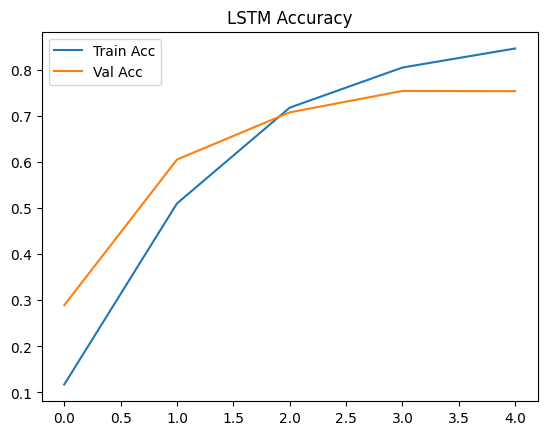

In [41]:
plt.plot(history_lstm.history["accuracy"], label="Train Acc")# Plot LSTM accuracy
plt.plot(history_lstm.history["val_accuracy"], label="Val Acc")
plt.legend()
plt.title("LSTM Accuracy")
plt.show()

In [42]:
# final train vs validation accuracy for LSTM
print("LSTM Final Train Accuracy:", history_lstm.history["accuracy"][-1])
print("LSTM Final Validation Accuracy:", history_lstm.history["val_accuracy"][-1])

LSTM Final Train Accuracy: 0.8467882871627808
LSTM Final Validation Accuracy: 0.7541229128837585


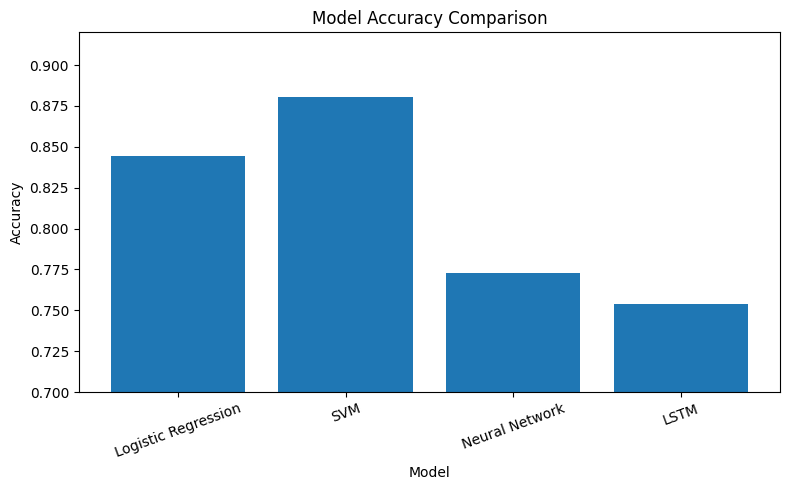

In [43]:
# ADDED: full model comparison chart
model_names = ["Logistic Regression", "SVM", "Neural Network", "LSTM"]
accuracies = [
    accuracy_score(y_val, y_pred),
    accuracy_score(y_val, svm_pred),
    history.history["val_accuracy"][-1],
    history_lstm.history["val_accuracy"][-1]
]

plt.figure(figsize=(8,5))
plt.bar(model_names, accuracies)
plt.title("Model Accuracy Comparison")
plt.xlabel("Model")
plt.ylabel("Accuracy")
plt.ylim(0.70, 0.92)
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

In [44]:
responses = {
    "card_arrival": "Your card usually arrives within 5 to 7 working days. Please check the delivery status in your app.",
    "activate_my_card": "You can activate your card using the mobile banking app by following the activation steps.",
    "cash_withdrawal_charge": "Cash withdrawal charges may apply depending on your account terms and withdrawal limits.",
    "card_not_working": "Please check whether your card is activated and whether international or online payments are enabled.",
    "refund_not_showing_up": "Refunds usually take a few business days to appear, depending on the merchant and bank processing time.",
    "beneficiary_not_allowed": "The beneficiary may not be supported due to transfer restrictions or account verification requirements.",
    "transfer_not_received": "Bank transfers can take some time. Please verify the recipient details and check the transfer status.",
    "balance_not_updated_after_bank_transfer": "Your balance may take some time to update after a transfer. Please wait and refresh the app.",
    "cash_withdrawal_not_recognised": "If you do not recognise a withdrawal, please freeze your card and contact support immediately.",
    "card_payment_not_recognised": "If you do not recognise a card payment, please review your recent transactions and report it through the app."
}

In [45]:
# Predict intent and return chatbot response
def predict_intent_and_response(user_text):
    user_tfidf = tfidf.transform([user_text])
    predicted_intent = best_svm.predict(user_tfidf)[0]
    
    response = responses.get(
        predicted_intent,
        f"The predicted intent is '{predicted_intent}', but no hardcoded response has been added for this intent yet."
    )
    
    return predicted_intent, response

In [46]:
# Test chatbot on one sample query
test_query = "My refund is still not showing in my account"

intent, reply = predict_intent_and_response(test_query)

print("User Query:", test_query)
print("Predicted Intent:", intent)
print("Chatbot Response:", reply)

NameError: name 'best_svm' is not defined

In [ ]:
# ADDED: safer chatbot demo without notebook input blocking
user_query = input("Enter your banking query: ")

intent, reply = predict_intent_and_response(user_query)

print("\nPredicted Intent:", intent)
print("Chatbot Response:", reply)


Predicted Intent: card_arrival
Chatbot Response: Your card usually arrives within 5 to 7 working days. Please check the delivery status in your app.
